# EDA for carbreakdown data

In deze notebook gaan we de dataset in in train_CarBreakDown onderzoeken. Eerst starten we met een algemeen zicht op de dataset via een describe. Dit word gevolgd door null waarde weg te halen want deze zullen de eind resultaten het meest beïnvloeden. Dan kijken we de verdelingen van de data per kollom om te zien als er dingen opvallen. Ten slotten kijken we nog voor enige afwijkingen.

## Obtain data in variabel
Eerst starten we met het inlezen van de data. Hierop voeren we direct een describe uit om een snel overzicht van de data te verkrijgen.


In [34]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# read csv file
df = pd.read_csv('../../csv/train/train_CarBreakDown.csv')
# print(f"Null value overview:\n{df.isnull().sum()}\n")
print(f"Total nulls in dataset: {df.isnull().sum().sum()}")
print(f"Gemiddelde nulls in dataset: {round(df.isnull().sum().mean())}")

totaal_records = len(df)
print(f"Totaal aantal records {totaal_records}")
df.describe(include='all')

Total nulls in dataset: 239
Gemiddelde nulls in dataset: 17
Totaal aantal records 1050


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
count,1050.000000,1029,1034.000000,1.033000e+03,1035.000000,1040.000000,1014.000000,1038.000000,1037,1036,995.000000,1037.000000,1033,1050.000000
unique,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,4,5,NaN,NaN,4,NaN
top,NaN,Ford,NaN,NaN,NaN,NaN,NaN,NaN,medium,petrol,NaN,NaN,summer,NaN
freq,NaN,194,NaN,NaN,NaN,NaN,NaN,NaN,428,435,NaN,NaN,386,NaN
mean,742.984762,NaN,9.399420,3.639119e+06,4368.929467,10681.075986,60.682779,38.861387,NaN,NaN,69.393768,6.972183,NaN,0.167619
std,430.089010,NaN,5.752228,2.585818e+07,2214.510223,9341.969609,20.298624,47.968702,NaN,NaN,15.570872,1.478278,NaN,0.373706
min,0.000000,NaN,0.000000,-1.829042e+02,-50.000000,10.869020,0.000000,1.011100,NaN,NaN,-13.171570,2.504369,NaN,0.000000
25%,372.250000,NaN,5.000000,8.338616e+04,2773.353090,3374.773323,47.377582,8.187057,NaN,NaN,58.902723,6.001099,NaN,0.000000
50%,740.500000,NaN,9.000000,1.202357e+05,3967.125562,8085.318122,60.528422,16.788852,NaN,NaN,69.504547,6.928004,NaN,0.000000
75%,1109.250000,NaN,14.000000,1.674871e+05,5432.498224,14455.318280,74.654436,44.308719,NaN,NaN,79.597898,8.022503,NaN,0.000000


### Eerste observaties

- **Bijna alle kolommen bevatten ontbrekende waarden**, behalve:
  - `id` (logisch)
  - `breakdown_next_30_days` (dit is ons doel om te berekenen)

- **Er zijn negatieve waarden gevonden in:**
  - `mileage_km`
  - `engine_hours`
  - `cleanliness_score`  

  Deze waarden zouden **niet negatief kunnen zijn**, wat mogelijk wijst op fouten in de data.

- **`oil_quality` wordt weergegeven als een percentage**, maar de **maximale waarde is 102%**, wat niet logisch is voor een percentage.

- **Hetzelfde probleem komt voor bij `cleanliness_score`**, waar waarden ook buiten de verwachte schaal lijken te vallen.

- **`driver_satisfaction` moet mogelijk ook verder gecontroleerd worden**, om na te gaan of de waarden binnen een geldige range vallen.

### Omgaan met NULL waarden

Uit de bovenstaande analyse is te zien dat 239 waarden over alle kollomen (1050) niet ingevuld zijn. Dit betekent dat we maximum 23% van de data verliezen, er van uit gaand dat elke NULL in een verschillend record voorkomt.

We kunnen hier op twee manier mee omgaan, amputatie of imputatie.

**Amputatie**: Het verwijderen van de rij of kollomen die null waarde bevatten om enkel over te blijven met ingevulde records. Dit is ten koste van de grote van de data set.

**Imputatie**: Het vervangen van de data, vaak door het gemiddelde of mediaan om de data volledig te maken. Dit kan enkel als de rest van de gegevens ok zijn en kan de gegevens veralgemene.

Zelfs als het niet exact 23%, maar bijvoorbeeld 15% zou zijn, 893 resterend in dat geval, zou dit ookal veel impact hebben op de resultaten. Dit komt omdat de dataset redelijk klein is. Het houdt ook geen rekening mee dat er andere redenen kunnen zijn dat records kunnen gedropt worden. Het is dus het beste om zoveel mogelijke kollomen te imputeren. Dit gaat niet altijd handig zijn zoals bij bijvoorbeeld `vehicle brand`, hier zal dan amputatie kunnen gebruikt worden.

## Per kollom null waarde behandeling

Nu gaan we elke kollom individueel af om te kijken wat er aangepast kan worden zoals het droppen/imputeren van null waarde. Er zijn twee soorten kollom in de dataset **numerieke en categorische**. 

Bij **numerieke kollommen** wordt er gekeken naar de verdeling van de waarde via een boxplot om te zien als er onwaarscheinlijke uitschieters zijn.

Bij **kollommen met categorische waarde** kan dit natuurlijk niet en wordt er hier via een barchart gekeken hoe de verdeling is tussen de verschillende categorieën. All deze kollomen hebben een `other` kollom en afhankelijk van de grote hier van kunnen de records hiervan ook gedropt worden omdat deze data niet specifiek genoeg is (het is well beter dan null). Dit maakt het beter om die kolom te bewaren waar mogelijk, omdat de `other` kolommen dan makkelijker gedropt kunnen worden.

### vehicle_brand
De **`vehicle_brand`** kolom bevat het merk van het voertuig. Deze categorische variabele kan gebruikt worden om verschillen in prestaties, onderhoud of betrouwbaarheid tussen merken te analyseren.

Kollom null waardes: 21 (2.0%)
vehicle_brand
Ford          194
Toyota        193
Volkswagen    143
BMW           125
Hyundai       101
Renault        97
Volvo          93
Kia            69
other          14
Name: count, dtype: int64


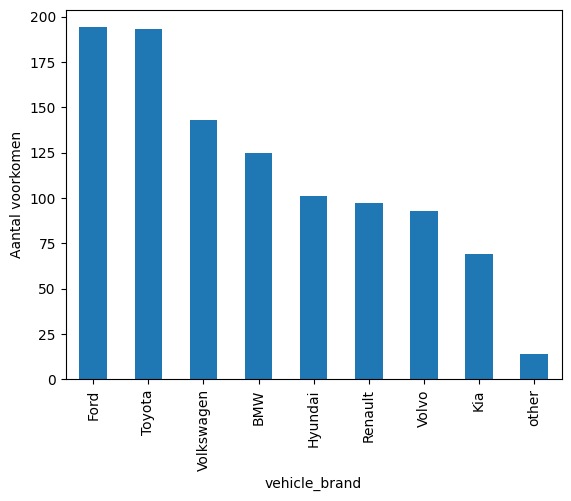

In [35]:
vehicle_brand = df['vehicle_brand']
print(f"Kollom null waardes: {vehicle_brand.isnull().sum()} ({(vehicle_brand.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.vehicle_brand.value_counts())
df['vehicle_brand'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')
plt.show()



`Vehicle_brand` is een **categorische kollom**, hierdoor wordt er zeker **geamputeerd**. Het heeft een boven gemiddeld aantal null waarden, maar de gemiddelde category nemen zou niet een goede oplossing zijn want dan wordt deze categorie over gerepresenteerd. Dit is natuurlijk niet goed om later een AI model op te trainen, dan zou ons AI model beginnen kunnen denken dat Fords sneller kapot kunnen gaan dan een Kia. We kunnen ook zorgen dat the ``other`` waarde blijft. Dit kan omdat het nog steeds op iets kan duiden. Interresant om te zien dat de merken **niet even verdeeld is** en sommige veel meer voorkomen dan andere.

Het resultaat is **21 gedropte kollomen**.

In [36]:
df.dropna(subset='vehicle_brand', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen


### vehicle_age_years
De **`vehicle_age_years`** kolom geeft de leeftijd van het voertuig weer in jaren. Oudere voertuigen hebben doorgaans meer slijtage en een grotere kans op defecten.



Kollom snel overzicht:
null waardes: 16 (1.52%)
gemiddelde: 9.385982230997039
median: 9.0
uitschieters: 0


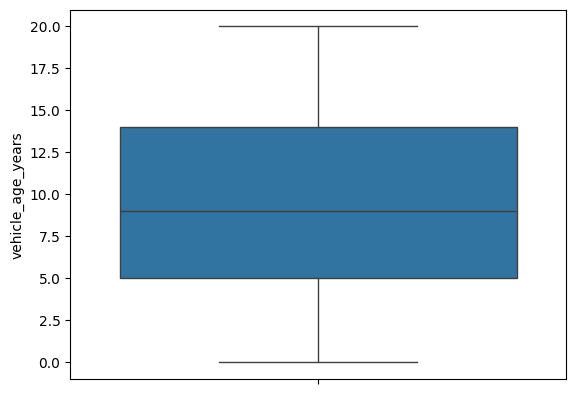

In [37]:
vehicle_age = df['vehicle_age_years']

print("Kollom snel overzicht:")
print(f"null waardes: {vehicle_age.isnull().sum()} ({(vehicle_age.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"gemiddelde: {vehicle_age.mean()}")
print(f"median: {vehicle_age.median()}")
print(f"uitschieters: {len(df[(df['vehicle_age_years'] >df['vehicle_age_years'].mean() + df['vehicle_age_years'].std()*2) | (df['vehicle_age_years'] < df['vehicle_age_years'].mean() - df['vehicle_age_years'].std()*2)])}")

sns.boxplot(data=df, y='vehicle_age_years')
plt.show()



``Vehicle_age_years`` is een **numerieke kollom**. Het is ook **normaal verdeelt**. Dit betekend dat we niet extra waarden moeten weg halen voor uitschieters en dat we veilig de null waarde kunnen **imputeren**. Deze imputatie wordt gedaan met **ronding** omdat alle waarde gehele getallen zijn van 0 tot en met 20.

In [38]:
df.fillna({'vehicle_age_years':vehicle_age.mean()},inplace=True) # use dictonairy to specify which collum to change
df['vehicle_age_years'] = df['vehicle_age_years'].round() # round because all other calues are whole numbers

print("Algemene Data Na aanpassing")
print(df['vehicle_age_years'].describe())

Algemene Data Na aanpassing
count    1029.000000
mean        9.379981
std         5.701425
min         0.000000
25%         5.000000
50%         9.000000
75%        14.000000
max        20.000000
Name: vehicle_age_years, dtype: float64


### mileage_km
De **`mileage_km`** kolom bevat het totale aantal gereden kilometers van het voertuig. Dit is een belangrijke indicator voor slijtage en wordt vaak gebruikt om onderhoudsbehoeften en de algemene staat van het voertuig te beoordelen.

In [39]:
df = df[
    (df['mileage_km'] <= 500_000) &   # verwijder >500k
    (df['mileage_km'] >= 0) &        # verwijder negatieve waarden
    (df['mileage_km'].notna())       # verwijder NaN
]

``Mileage_km`` is een **numerieke kollom**. Wanneer je eerst de data bekijkt zie je dat deze kollom een harde right skew heeft.

<img src="../../assets/mileageKMSkew.png" alt="boxplot van Mileage_km met zware right skew" width="400">

Dit heeft als gevolg dat het gemiddelde een slecht maat is om te gebruiken. De mediaan is hier beter met **120361.02** wat dicht bij ligt bij de waarde van een auto van 10 jaar volgens een snelle zoekopdracht. 

Door de heel extreme skewing in de data gaat zelfs **2 * standaard divatie niet echt betrouwbaar** meer zijn dus hebben we geopteerd om alle auto's met een afstand boven **500 000 km** te droppen. Alle waarde boven dit worden verwijderd. Het zelfde wordt gedaan met **negatieve waarde** want deze zouden niet mogelijk zijn ten slotte gebeurd hetzelfde voor null waarde. 

### engine_hours
De **`engine_hours`** kolom toont het totale aantal uren dat de motor heeft gedraaid. Dit kan extra inzicht geven in gebruiksintensiteit, vooral bij voertuigen die veel stationair draaien.

In [40]:
engine_hours = df['engine_hours']

print("Kollom snel overzicht:   ")
print(f"null waardes: {engine_hours.isnull().sum()} ({(engine_hours.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"gemiddelde: {engine_hours.mean()}")
print(f"mediaan: {engine_hours.median()}")
print(f"uitschieters: {len(df[(df['engine_hours'] >df['engine_hours'].mean() + df['engine_hours'].std()*2) | (df['engine_hours'] < df['engine_hours'].mean() - df['engine_hours'].std()*2)])}")


Kollom snel overzicht:   
null waardes: 14 (1.33%)
gemiddelde: 4344.735099022446
mediaan: 3957.808917676169
uitschieters: 68


nieuwe gemiddelde: 4386.79662803006
nieuwe mediaan: 4004.7313963339257


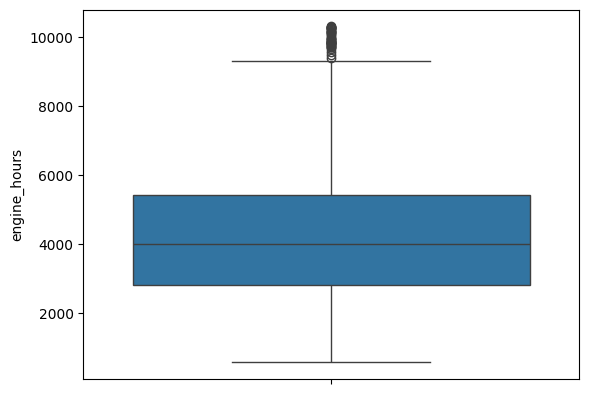

In [41]:
# replace negative values with median values
df.loc[df['engine_hours'] < 0, 'engine_hours'] = df.loc[df['engine_hours'] >= 0, 'engine_hours'].median() 
print(f"nieuwe gemiddelde: {df['engine_hours'].mean()}")
print(f"nieuwe mediaan: {df['engine_hours'].median()}")
sns.boxplot(data=df, y='engine_hours')
plt.show()

``Engine_hours`` is een **numerieke kollom**. Deze kollom is **vergelijkbaar met de ``milleage_km`` kollom** maar zonder de skew. Het meest op opvallend is de **11 negatieve waarde** in de kollom wat normaal gezien niet mogelijk zou moeten zijn. Deze worden dan naar de **mediaan gezet** samen met de null waardes.

In [42]:
df.fillna({'engine_hours':engine_hours.median()},inplace=True) # use dictonairy to specify which collum to change
df = df.fillna({'engine_hours': df['engine_hours'].median()})

# drop not logical values => having a age less then 3 with 9000 + engine hours 
df = df.drop(df[(df['engine_hours'] > 9000) & (df['vehicle_age_years'] < 3)].index) 

print("Algemene Data Na aanpassing")
print(df['engine_hours'].describe())

Algemene Data Na aanpassing
count      970.000000
mean      4335.905496
std       2075.464043
min        579.571845
25%       2815.440512
50%       3957.808918
75%       5385.684674
max      10298.582128
Name: engine_hours, dtype: float64


### last_service_km_ago
De **`last_service_km_ago`** kolom geeft aan hoeveel kilometer het voertuig heeft gereden sinds de laatste onderhoudsbeurt. Dit kan helpen om te bepalen of een voertuig mogelijk binnenkort opnieuw onderhoud nodig heeft.

Kollom snel overzicht:
null waardes: 9 (0.86%)
gemiddelde: 10707.42239705834
mediaan: 8117.235168147471
uitschieters: 55


<Axes: ylabel='last_service_km_ago'>

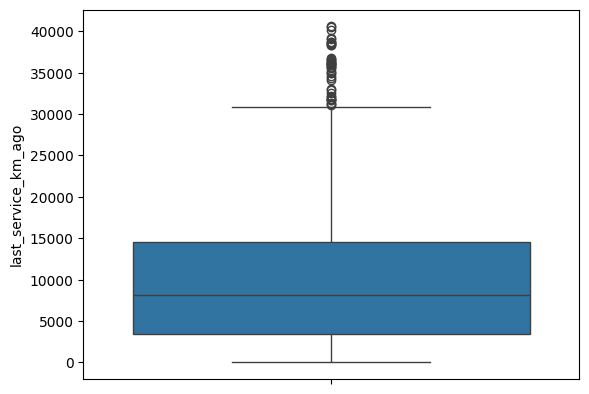

In [43]:
last_service_km_ago = df['last_service_km_ago']

print("Kollom snel overzicht:")
print(f"null waardes: {last_service_km_ago.isnull().sum()} ({(last_service_km_ago.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"gemiddelde: {last_service_km_ago.mean()}")
print(f"mediaan: {last_service_km_ago.median()}")
print(f"uitschieters: {len(df[(df['last_service_km_ago'] >df['last_service_km_ago'].mean() + df['last_service_km_ago'].std()*2) | (df['last_service_km_ago'] < df['last_service_km_ago'].mean() - df['last_service_km_ago'].std()*2)])}")

sns.boxplot(data=df, y='last_service_km_ago')


``Last_service_km_ago`` is een **numerieke kollom**. Het is een redelijk simpele kollom het is right skewed maar is nog steeds logisch **40592.195120 km** rijden is nog steeds mogelijk, enkel onwaarschijnlijk. Via een snelle zoekopdracht vindt je dat **15 000 km het gemiddelde is tussen service controles** wat opvallend hoger ligt dan dit gemiddelde van de kollom. Dit komt vast omdat de kollom aanduid wanneer de test voor crash gebeurt is waardoor het logisch is dat het gemiddelde lager ligt.

Er worden well nog wat records gedropt. Als de ``milleage_km`` kleiner is dan de ``last_service_km_ago`` dan is er iets fout. Dit koste **18 records**.

In [44]:
df.fillna({'last_service_km_ago': last_service_km_ago.mean()},inplace=True) # use dictonairy to specify which collum to change

df = df.drop(df[df['last_service_km_ago'] > df['mileage_km']].index) # drop not logical values => last service cannot be higher then the mileage of the car because to have distance between services the car also gets milleage

print("Algemene Data Na aanpassing")
print(df['last_service_km_ago'].describe())

Algemene Data Na aanpassing
count      952.000000
mean     10676.289211
std       9242.151986
min         10.869020
25%       3495.011939
50%       8242.277377
75%      14441.195308
max      40592.195120
Name: last_service_km_ago, dtype: float64


### oil_quality_pct
De **`oil_quality_pct`** kolom geeft een schatting van de kwaliteit van de motorolie in percentage (0–100%). Een lagere waarde kan aangeven dat de olie vervuild of versleten is en mogelijk vervangen moet worden.

Kollom snel overzicht:
null waardes: 34 (3.24%)
gemiddelde: 60.56607323387701
mediaan: 60.53778569019714
uitschieters: 22


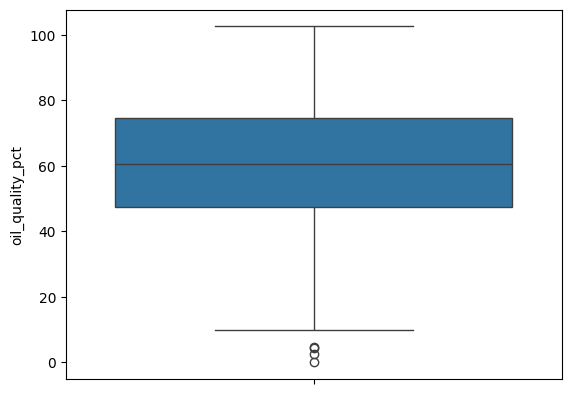

In [45]:
oil_quality_pct = df['oil_quality_pct']

print("Kollom snel overzicht:")
print(f"null waardes: {oil_quality_pct.isnull().sum()} ({(oil_quality_pct.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"gemiddelde: {oil_quality_pct.mean()}")
print(f"mediaan: {oil_quality_pct.median()}")
print(f"uitschieters: {len(df[(df['oil_quality_pct'] >df['oil_quality_pct'].mean() + df['oil_quality_pct'].std()*2) | (df['oil_quality_pct'] < df['oil_quality_pct'].mean() - df['oil_quality_pct'].std()*2)])}")

sns.boxplot(data=df, y='oil_quality_pct')
plt.show()

``Oil_quality_pct`` is een **numerieke kollom en een percentage**. Het is **normaal verdeelt** en er zijn weinig uitschieters. Hier worden de null waardes door het gemiddelde vervangen. Dit komt omdat het gemiddelde en de mediaan dicht bij elkaar liggen.

Voor logische percentages te hebben werden de **percentages goter naar honderd naar het gemiddelde** gezet.

In [46]:
df.fillna({'oil_quality_pct': oil_quality_pct.mean()},inplace=True) # use dictonairy to specify which collum to change

df.loc[df['oil_quality_pct'] > 100, 'oil_quality_pct'] = df['oil_quality_pct'].mean() # this collum is a percentage and cannot be higherthen 100, replace it with mean

print("Algemene Data Na aanpassing")
print(df['oil_quality_pct'].describe())

Algemene Data Na aanpassing
count    952.000000
mean      60.054428
std       19.434123
min        0.000000
25%       47.575278
50%       60.566073
75%       72.838070
max      100.000000
Name: oil_quality_pct, dtype: float64


### avg_trip_length_km
De **`avg_trip_length_km`** kolom geeft de gemiddelde afstand per rit in kilometers weer. Kortere ritten kunnen bijvoorbeeld leiden tot meer slijtage omdat de motor minder vaak volledig op temperatuur komt.


Kollom snel overzicht:
null waardes: 12 (1.14%)
gemiddelde: 38.88283177274568
mediaan: 16.67931633526197
uitschieters: 72


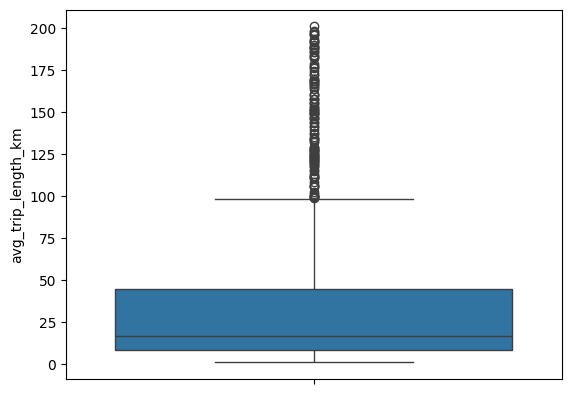

In [47]:
avg_trip_length_km = df['avg_trip_length_km']

print("Kollom snel overzicht:")
print(f"null waardes: {avg_trip_length_km.isnull().sum()} ({(avg_trip_length_km.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"gemiddelde: {avg_trip_length_km.mean()}")
print(f"mediaan: {avg_trip_length_km.median()}")
print(f"uitschieters: {len(df[(df['avg_trip_length_km'] >df['avg_trip_length_km'].mean() + df['avg_trip_length_km'].std()*2) | (df['avg_trip_length_km'] < df['avg_trip_length_km'].mean() - df['avg_trip_length_km'].std()*2)])}")

sns.boxplot(data=df, y='avg_trip_length_km')
plt.show()

``Avg_trip_length_km`` is een **numerieke kollom**. Het is **vrij hard rechtsgeskewed**, zoals te zien in bovenstaand boxplot. De waarde die er aanwezig zijn, zijn redelijk reël waardoor **niets aan de data kan worden aangepast** behalve de **null waarde vervangen met de mediaan** want gemiddelde is minder betrouwbaar.

In [48]:
df.fillna({'avg_trip_length_km': avg_trip_length_km.mean()},inplace=True) # use dictonairy to specify which collum to change


df.loc[df['avg_trip_length_km'] < 0, 'avg_trip_length_km'] = df['avg_trip_length_km'].median()
print("Algemene Data Na aanpassing")
print(df['avg_trip_length_km'].describe())


Algemene Data Na aanpassing
count    952.000000
mean      38.882832
std       47.586301
min        1.011100
25%        8.407932
50%       17.248151
75%       44.125884
max      201.015553
Name: avg_trip_length_km, dtype: float64


### weather_exposure
De **`weather_exposure`** kolom beschrijft in welke mate het voertuig wordt blootgesteld aan weersomstandigheden. Mogelijke waarden zijn **low**, **medium** en **high**. Meer blootstelling kan leiden tot snellere slijtage of vervuiling.

Kollom null waardes: 13 (1.24%)
weather_exposure
medium    387
low       348
high      185
other      19
Name: count, dtype: int64


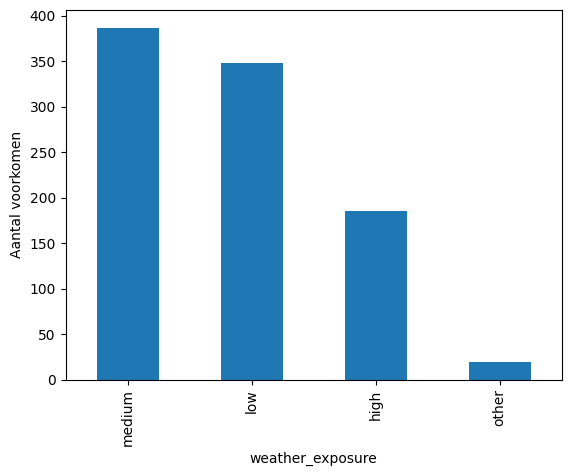

In [49]:
weather_exposure= df['weather_exposure']
print(f"Kollom null waardes: {weather_exposure.isnull().sum()} ({(weather_exposure.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.weather_exposure.value_counts())
df['weather_exposure'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')
plt.show()

``Weather_exposure`` is een **categorische kollom**. Dit volgt dezelfde logica als bij ``vehicle_brand`` waar we the null waarde droppen **ten koste van 12 records** en behouden de ``other waarden`` om niet de grootste waarde over te representeren.

In de data set komt medium weer verstoring het meest voor.

In [50]:
df.dropna(subset='weather_exposure', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen


### fuel_type
De **`fuel_type`** kolom geeft het type brandstof of aandrijving van het voertuig aan, zoals **petrol**, **diesel**, **hybrid** of **electric**. Dit kan invloed hebben op onderhoud, prestaties en gebruikspatronen.



Kollom null waardes: 14 (1.33%)
fuel_type
petrol      382
diesel      332
hybrid      141
electric     50
other        20
Name: count, dtype: int64


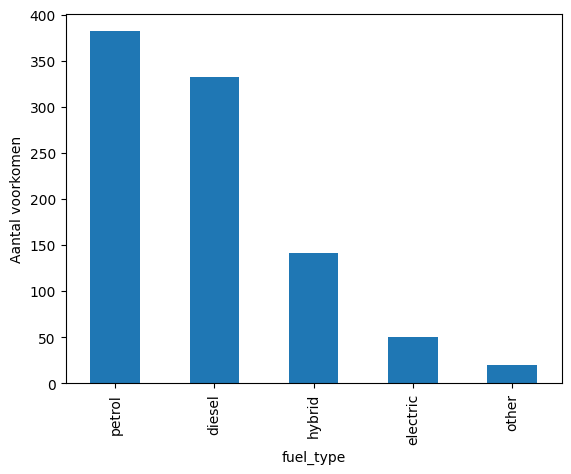

In [51]:
fuel_type= df['fuel_type']
print(f"Kollom null waardes: {fuel_type.isnull().sum()} ({(fuel_type.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.fuel_type.value_counts())
df['fuel_type'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')
plt.show()

``Fuel_type`` is een **catigorische kollom**. Net zoals de andere worden de **null waarden gedropt met 14 records** in totaal. De other kollom blijft ook weer behouden om niet een andere kollom te iver representeren.

De grootste aantal auto's gebruiken in de dataset fosiele brandstof.

In [52]:
df.dropna(subset='fuel_type', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen

### cleanliness_score
De **`cleanliness_score`** kolom geeft een score voor de algemene netheid van het voertuig op een schaal van 0 tot 100. Dit kan een indicatie zijn van hoe goed een voertuig wordt onderhouden door de bestuurder.

Kollom snel overzicht:
null waardes: 45 (4.29%)
gemiddelde: 69.70875090091461
mediaan: 69.62991411892966
uitschieters: 27


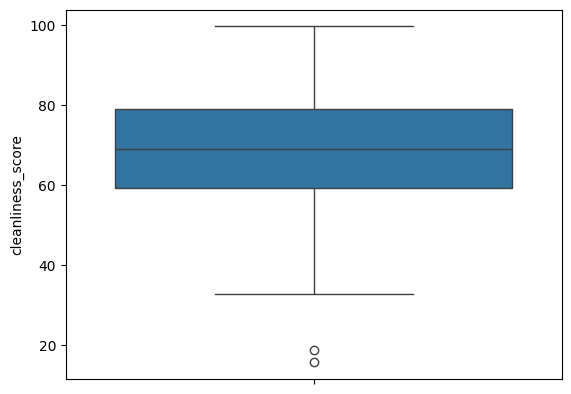

In [53]:
cleanliness_score = df['cleanliness_score']

print("Kollom snel overzicht:")
print(f"null waardes: {cleanliness_score.isnull().sum()} ({(cleanliness_score.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"gemiddelde: {cleanliness_score.mean()}")
print(f"mediaan: {cleanliness_score.median()}")
print(f"uitschieters: {len(df[(df['cleanliness_score'] >df['cleanliness_score'].mean() + df['cleanliness_score'].std()*2) | (df['cleanliness_score'] < df['cleanliness_score'].mean() - df['cleanliness_score'].std()*2)])}")

df.loc[df['cleanliness_score'] < 0,'cleanliness_score'] = df.loc[df['cleanliness_score'] > 0,'cleanliness_score'].mean() # replace the 1 negative value with the mean
df.loc[df['cleanliness_score'] > 100,'cleanliness_score'] = df.loc[df['cleanliness_score'] < 100,'cleanliness_score'].mean() # cleanliness_score has a range to 100 and cannot be higher so replace those with the mean
sns.boxplot(data=df, y='cleanliness_score')
plt.show()

``Cleanliness_score`` is een **numerique kollom**.  Het is **normaal verdeelt** en opvallend **veel null waarde**. Hier kunnen deze waarde weer door het gemiddelde vervangen worden. Weer omdat de mediaan en gemiddelde dicht liggen op elkaar.

De ``cleanliness_score`` is een **waarde tussen 0 en 100**. Andere waardes moeten vervangen/gedropt worden. Net zoals altijd worden ze **vervangen** door het gemiddelde om de data te behouden.

In [54]:
df.fillna({'cleanliness_score': cleanliness_score.mean()},inplace=True) # use dictonairy to specify which collum to change
print("Algemene Data Na aanpassing")
print(df['cleanliness_score'].describe())

Algemene Data Na aanpassing
count    925.000000
mean      68.880228
std       13.674797
min       15.706719
25%       59.795529
50%       69.708751
75%       78.591349
max       99.678105
Name: cleanliness_score, dtype: float64


### driver_satisfaction_score
De **`driver_satisfaction_score`** kolom bevat een tevredenheidsscore van de bestuurder op een schaal van 1 tot 10. Deze score kan helpen om subjectieve ervaringen met het voertuig te analyseren.

Kollom snel overzicht:
Kollom null waardes: 12 (1.14%)
Kollom gemiddelde: 6.983257675996256
Kollom median: 6.92800360648778
Kollom uitschieters: 36


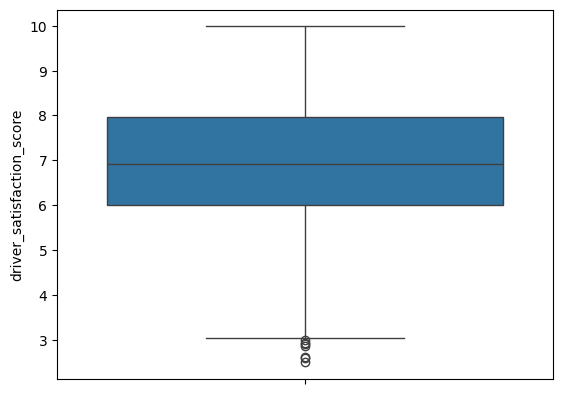

In [55]:
driver_satifaction_score = df['driver_satisfaction_score']

print("Kollom snel overzicht:")
print(f"Kollom null waardes: {driver_satifaction_score.isnull().sum()} ({(driver_satifaction_score.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {driver_satifaction_score.mean()}")
print(f"Kollom median: {driver_satifaction_score.median()}")
print(f"Kollom uitschieters: {len(df[(df['driver_satisfaction_score'] >df['driver_satisfaction_score'].mean() + df['driver_satisfaction_score'].std()*2) | (df['driver_satisfaction_score'] < df['driver_satisfaction_score'].mean() - df['driver_satisfaction_score'].std()*2)])}")

df.loc[df['driver_satisfaction_score'] > 10,'driver_satisfaction_score'] = df.loc[df['driver_satisfaction_score'] < 10,'driver_satisfaction_score'].mean() # driver_satisfaction_score has a range from 1 to 10 and cannot be higher so replace those with the mean
sns.boxplot(data=df, y='driver_satisfaction_score')
plt.show()

``Driver_satisfaction_score`` is een **numerieke kollom**. Het is **normaal verdeelt** met enkele uitschieters die redelijk normaal zijn bij een score zoals dit. De null waarden worden zoals alteid door het **gemiddelde vervangen**.

De score heeft een **range van 0-10** enkele waarden zijn hoger en moeten ook vervangen worden

In [56]:
df.fillna({'driver_satisfaction_score': driver_satifaction_score.mean()},inplace=True) # use dictonairy to specify which collum to change
print("Algemene Data Na aanpassing")
print(df['driver_satisfaction_score'].describe())

Algemene Data Na aanpassing
count    925.000000
mean       6.924212
std        1.419478
min        2.504369
25%        6.015127
50%        6.923436
75%        7.943020
max        9.984313
Name: driver_satisfaction_score, dtype: float64


### tyre_type
De **`tyre_type`** kolom beschrijft het type banden dat op het voertuig wordt gebruikt, bijvoorbeeld **summer**, **winter** of **all season** banden. Het type band kan invloed hebben op veiligheid, grip en prestaties in verschillende weersomstandigheden.

Kollom null waardes: 15 (1.43%)
tyre_type
summer        341
winter        290
all-season    265
other          14
Name: count, dtype: int64


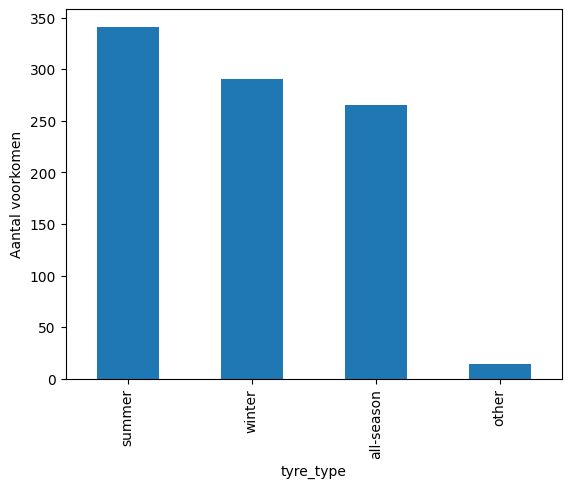

In [57]:
tyre_type= df['tyre_type']
print(f"Kollom null waardes: {tyre_type.isnull().sum()} ({(tyre_type.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.tyre_type.value_counts())
df['tyre_type'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')
plt.show()

``Tyre_type`` is een **categorische kollom**. De kollommen **zijn niet eerlijk verdeeld**. Net zoals altijd bij categorische data droppen we de null waardes deze keer met **14 records** en behouden we de other waarde om niet te veel andere categorieën te overrepresenteren.

In [58]:
df.dropna(subset='tyre_type', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen

## Data analyse + hypotheses

Ok, na het het scrubben van de data gaan we nog kort de data annalyseren via een correlatie matrix en hier hypotheses uit maken.

,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,cleanliness_score,driver_satisfaction_score
vehicle_age_years,1.000000,0.027129,0.036416,0.051373,-0.004158,0.056718,0.011735,0.010856
mileage_km,0.027129,1.000000,0.959098,-0.032712,0.024994,-0.048541,0.033279,0.073109
engine_hours,0.036416,0.959098,1.000000,-0.028617,0.028025,-0.047695,0.026061,0.079635
last_service_km_ago,0.051373,-0.032712,-0.028617,1.000000,0.057718,0.057400,0.027931,0.008691
oil_quality_pct,-0.004158,0.024994,0.028025,0.057718,1.000000,-0.011437,-0.024732,-0.010760
avg_trip_length_km,0.056718,-0.048541,-0.047695,0.057400,-0.011437,1.000000,0.012879,0.039667
cleanliness_score,0.011735,0.033279,0.026061,0.027931,-0.024732,0.012879,1.000000,-0.015063
driver_satisfaction_score,0.010856,0.073109,0.079635,0.008691,-0.010760,0.039667,-0.015063,1.000000


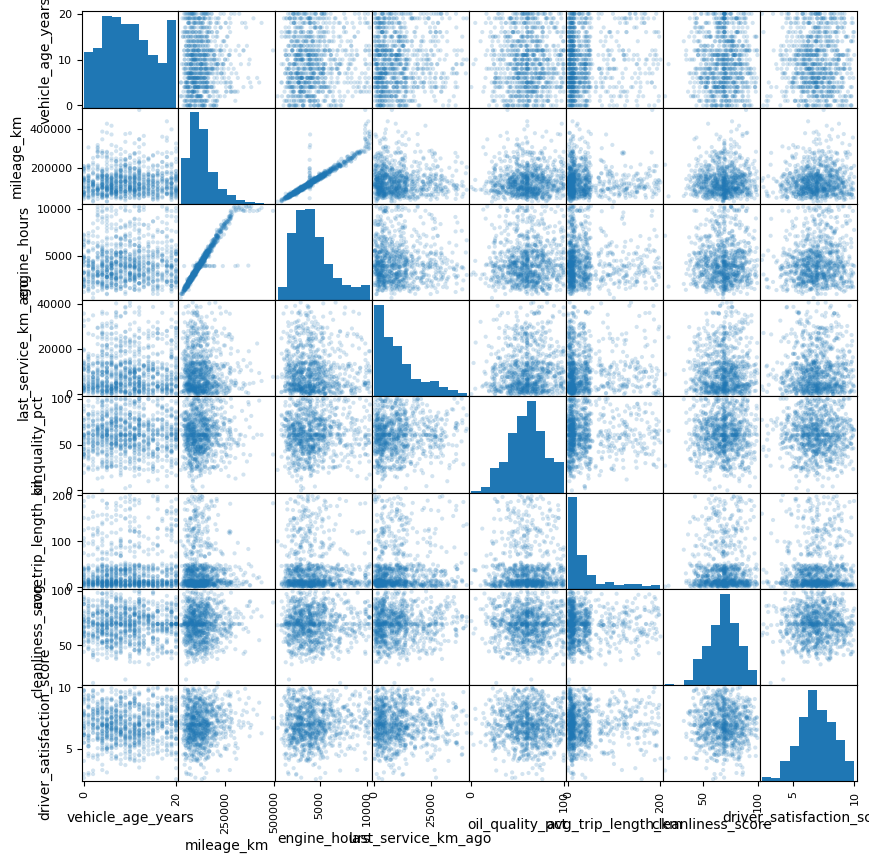

In [59]:
from pandas.plotting import scatter_matrix
scatter_matrix(df[['vehicle_age_years','mileage_km','engine_hours','last_service_km_ago','oil_quality_pct','avg_trip_length_km','cleanliness_score','driver_satisfaction_score']], alpha=0.2, figsize=(10,10))
df[['vehicle_age_years','mileage_km','engine_hours','last_service_km_ago','oil_quality_pct','avg_trip_length_km','cleanliness_score','driver_satisfaction_score']].corr()

De matrix toont de verdeling van elke variabele en de relaties tussen alle variabelen. De meeste combinaties vormen een losse puntenwolk, wat betekent dat er **weinig tot geen sterke verbanden** zijn tussen die variabelen. Eén duidelijke uitzondering is ``mileage_km`` en`` engine_hours``, waar een **sterke lineaire relatie** zichtbaar is: hoe meer kilometers een voertuig heeft gereden, hoe meer motoruren het heeft. 

De histogrammen op de diagonaal laten ook zien dat sommige variabelen (zoals ``mileage_km``) scheef verdeeld zijn, terwijl andere (zoals ``oil_quality_pct`` en ``driver_satisfaction_score``) meer rond een gemiddelde gecentreerd zijn.

Ook kunnen we afleiden dat de histogrammen voor de ``[mileage_km, last_service_km_ago, avg_trip_lenght_km]``, allemaal right skewed zijn. En dus onze data voor die kollomen aan het scheef trekken.


We hebben ook geprobeerd om volgende code snippet te gebruiken.
```python
df.loc[df['mileage_km'] < 400_000, 'mileage_km'] = (
    df.loc[df['mileage_km'] < 400_000, 'vehicle_age_years']
    * df['mileage_km'].median()
)
```
Dit zorgt dat als een auto minder dan 400 000 km heeft, wordt die kilometerstand vervangen door: leeftijd van de auto × de gemiddelde middenwaarde van alle kilometerstanden. Dit zorgde ervoor dat al onze data meer rond de mediaan hing. Dit heeft uiteindelijk ook nietmeer veel geholpen en hebben we dus ook niet verder geïmplementeerd. 

### `engine_hours` vs `mileage_km`

We zien dus een sterk lineaire relatie tussen `engine_hours` en ``mileage_km``. Het is logisch dat deze 2 kollomen zo sterk samen hangen. Want hoe verder je rijd, hoe langer je motor zal hebben gedraaid. Laten we dus starten met onrealistische outliers eruit te filteren. Deze kunnen we gemakelijk vinden aan de hand van een boxplot.

<Figure size 600x600 with 0 Axes>

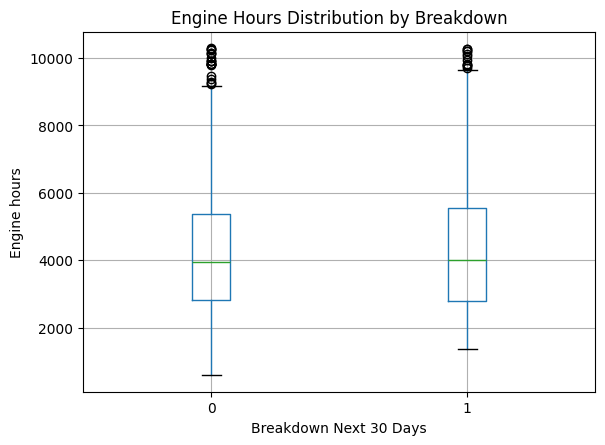

In [60]:
plt.figure(figsize=(6,6))

df.boxplot(column="engine_hours", by="breakdown_next_30_days")

plt.xlabel("Breakdown Next 30 Days")
plt.ylabel("Engine hours")
plt.title("Engine Hours Distribution by Breakdown")
plt.suptitle("")
plt.show()

We verwijderen bij ``engine_hours`` de outliers die buiten de normale grenzen van de boxplot vallen. Deze waarden zijn waarschijnlijk niet representatief voor het typische gebruik van een voertuig. We kunnen dus zeggen dat er veel voertuigen zijn die na een lange tijd niet naar de garage gaan maar toch geen breakdown krijgen.

Door deze extreme waarden weg te halen, wordt het model sneller geneigd om een 1 (kans op breakdown) te voorspellen wanneer de motoruren erg hoog zijn. Dit sluit aan bij het hoofddoel van dit project: een AI-model maken dat eerder waarschuwt dat een auto mogelijk kapot zal gaan.

Het is namelijk beter dat het model soms te voorzichtig is en een foutieve waarschuwing geeft (waardoor je misschien onnodig naar de garage gaat), dan dat het een probleem mist en je uiteindelijk stilvalt op de autosnelweg :)

Daarom zullen we alle motoruren boven de 9 000 uren verwijderen en waar die niet kapot gaat verwijderen.

In [61]:
df = df[~(
    (df["breakdown_next_30_days"] == 0) &
    (df["engine_hours"] > 9000)
)]

Nu we de outliers hebben verwijderd, kunnen we beter analyseren wat er precies gebeurt tussen deze twee kolommen. Eerst passen we **lineaire regressie** toe. Hiermee kunnen we zien hoe de punten in de dataset zich verhouden tot een rechte lijn die de algemene trend van de data weergeeft. Zo krijgen we een beter beeld van de relatie tussen beide variabelen en hoe sterk die samenhang is.

Bij deze regressielijn tekenen we ook twee grenslijnen (boundary lines). Deze liggen symmetrisch rond de regressielijn, waarbij de regressielijn de symmetrie-as vormt. Idealiter zou er geen data buiten deze grenzen mogen liggen. Alle datapunten die toch buiten deze lijnen vallen, worden daarom verwijderd.

De reden hiervoor is dat deze waarden waarschijnlijk niet realistisch zijn en het model kunnen verstoren. We hebben eerst geprobeerd om deze punten te vervangen door de waarde op de regressielijn, maar dit had weinig invloed op het uiteindelijke resultaat. Daarom hebben we uiteindelijk gekozen om deze punten volledig uit de dataset te verwijderen, en zijn we met deze aanpak verder gegaan.

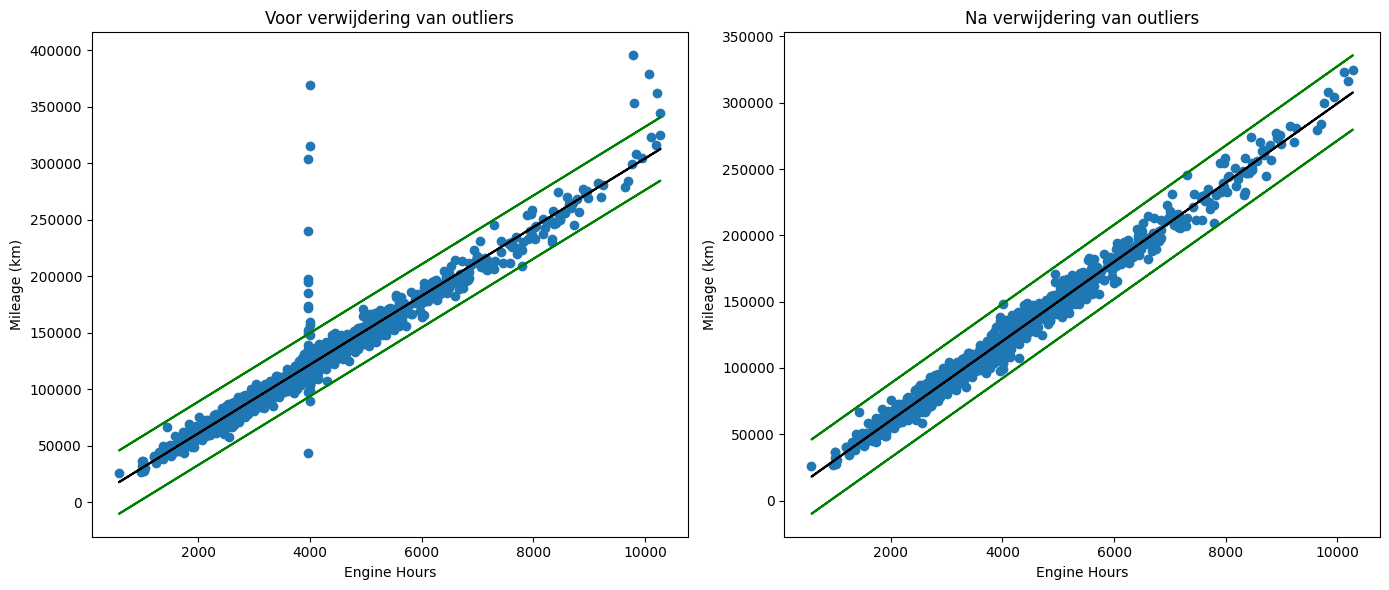

In [62]:
from sklearn.linear_model import LinearRegression

X = df['engine_hours'].values.reshape(-1,1)
y = df['mileage_km'].values

model = LinearRegression().fit(X,y)
model.score(X,y)
y_pred = model.predict(X)

# Maak subplots: 1 rij, 2 kolommen
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Eerste plot
axes[0].scatter(X, y)
axes[0].plot(X, y_pred, color='black')
axes[0].plot(X, y_pred + 28000, color='green')
axes[0].plot(X, y_pred - 28000, color='green')
axes[0].set_xlabel('Engine Hours')
axes[0].set_ylabel('Mileage (km)')
axes[0].set_title('Voor verwijdering van outliers')


outliers = []

upper = y_pred + 28_000
lower = y_pred - 28_000

mask_outliers = (df['mileage_km'].values > upper) | (df['mileage_km'].values < lower)
outlier_index = df.index[mask_outliers]
outliers = outlier_index.tolist()

df = df.drop(index=outlier_index)

X = df['engine_hours'].values.reshape(-1,1)
y = df['mileage_km'].values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# Tweede plot (zelfde data, kan verschillen als je iets anders wilt)
axes[1].scatter(X, y)
axes[1].plot(X, y_pred, color='black')
axes[1].plot(X, y_pred + 28000, color='green')
axes[1].plot(X, y_pred - 28000, color='green')
axes[1].set_xlabel('Engine Hours')
axes[1].set_ylabel('Mileage (km)')
axes[1].set_title('Na verwijdering van outliers')

plt.tight_layout()
plt.show()

Nu dat we onze sterkste relatie `engine_hours` en `mileage_km` hebben helemaal proper gecleaned en onrealistische data eruit hebben gehaald kunnen we hetzelfde doen voor 2 andere. Zoals we al eerder hebben gezegd zijn de kilometer kollommen,
``[mileage_km, last_service_km_ago, avg_trip_lenght_km]``, heel erg geright skewed. Om dit te kunnen op te lossen gaan we dit hetzelfde doen als bij `engine_hours` wat voor de lineare regressie is gebeurd.

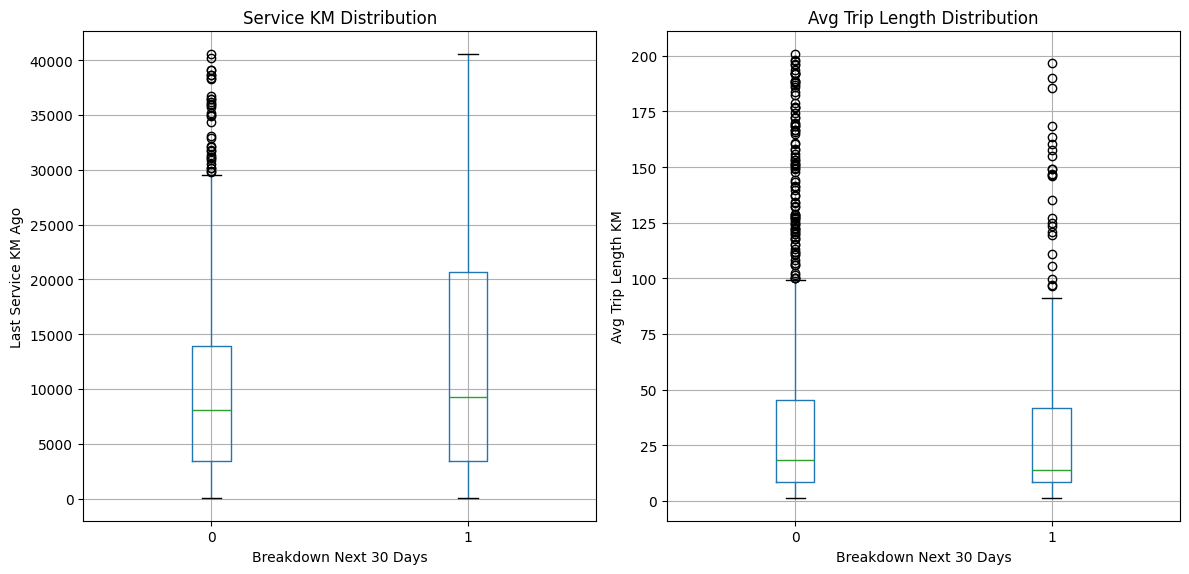

In [63]:
# Maak subplots: 1 rij, 2 kolommen
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Eerste boxplot: last_service_km_ago
df.boxplot(column="last_service_km_ago", by="breakdown_next_30_days", ax=axes[0])
axes[0].set_xlabel("Breakdown Next 30 Days")
axes[0].set_ylabel("Last Service KM Ago")
axes[0].set_title("Service KM Distribution")

# Tweede boxplot: avg_trip_length_km
df.boxplot(column="avg_trip_length_km", by="breakdown_next_30_days", ax=axes[1])
axes[1].set_xlabel("Breakdown Next 30 Days")
axes[1].set_ylabel("Avg Trip Length KM")
axes[1].set_title("Avg Trip Length Distribution")

# Verwijder de automatische suptitle van pandas boxplot
plt.suptitle("")
plt.tight_layout()
plt.show()

We verwijderen bij ``Last_service_km_ago`` de outliers die buiten de normale grenzen van de boxplot vallen. Deze waarden zijn waarschijnlijk niet representatief voor het typische gebruik van een voertuig. Net zoals we eerder zagen bij ``engine_hours``, zijn er veel voertuigen die lange tijd niet naar de garage gaan maar toch geen breakdown krijgen.

Door deze extreme waarden te verwijderen, wordt het model gevoeliger voor situaties waarin de kans op een breakdown groter is, bijvoorbeeld wanneer een voertuig lange tijd niet naar de garage is geweest of wanneer de gemiddelde afstand per rit erg hoog is. Dit sluit goed aan bij het hoofddoel van dit project: een AI-model ontwikkelen dat vroegtijdig waarschuwt voor mogelijk falende voertuigen.

Het is namelijk beter dat het model soms te voorzichtig is en een foutieve waarschuwing geeft (waardoor je misschien onnodig naar de garage gaat), dan dat het een probleem mist en je uiteindelijk stilvalt op de autosnelweg :)

Daarom verwijderen we alle voertuigen waarvan de afstand sinds de laatste garagebeurt groter is dan 30 000 km en die toch geen problemen hebben gehad. Hetzelfde doen we voor voertuigen die gemiddeld meer dan 100 km per rit afleggen maar geen breakdown ervaren.

In [64]:
df = df[~(
    (df["breakdown_next_30_days"] == 0) &
    (df["last_service_km_ago"] > 30000)
)]
 
df = df[~(
    (df["breakdown_next_30_days"] == 0) &
    (df["avg_trip_length_km"] > 100)
)]

Natuurlijk zijn er ook meerdere kolommen die gecontroleerd moeten worden, maar deze zijn besproken in [Data Cleaning Notebook](./AnalysisIndividualColums.ipynb).  

Om het kort te houden, hebben we alleen voor deze drie kolommen een harde scheidslijn kunnen maken. Bij de andere kolommen ligt de verdeling van de data tussen “kapot” (0) en “niet kapot” (1) grotendeels gelijk, waardoor het weinig zin heeft om daar gegevens weg te filteren die eigenlijk volledig normaal zijn.

Ook is er een deep dive nog gebeurd in de kolom `mileage_km` als je meer info rond deze analyse wilt. Lees dan voor de [Mileage km analyse notebook](../../Arne/analysis%20Mileage.ipynb)

Om het kort te houden staat in deze notebook gewoon nog meer ondervindingen die we hebben gemaakt over de kollom `mileage_km`



## Export to file

Nu we alle data hebben geanalyseerd en tevreden zijn met de uitgevoerde cleaning, kunnen we het bestand exporteren naar een CSV. Dit stelt ons in staat om het AI-model te trainen, zie [AI Model Trainen Notebook](../Model/Prediction_model.ipynb).

In [65]:
# df = df[df['vehicle_age_years'] >= 3]

In [66]:
df.to_csv('../../csv/new_train_data/train_CarBreakDown.csv')